This code was was built to evaluate the total energies on the 4 DNA sequences simulated. The data needed to run it collected with the help of energies.py.

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')
%cd /content/gdrive/MyDrive/'Colab Notebooks'/DNA_Final1/TotalVsTime

Mounted at /content/gdrive
/content/gdrive/MyDrive/Colab Notebooks/DNA_Final1/TotalVsTime


In [2]:
import csv
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

In [3]:
def load_energies_csv(path):
    energies = {}
    with open(path, "r", newline="") as f:
        reader = csv.DictReader(f)
        for field in reader.fieldnames:
            energies[field] = []
        for row in reader:
            for key in reader.fieldnames:
                val = row[key]
                energies[key].append(None if val in ("", None) else float(val))
    return energies

def clean_segment(x):
    arr = np.array([np.nan if v is None else v for v in x], dtype=float)
    return arr[~np.isnan(arr)]

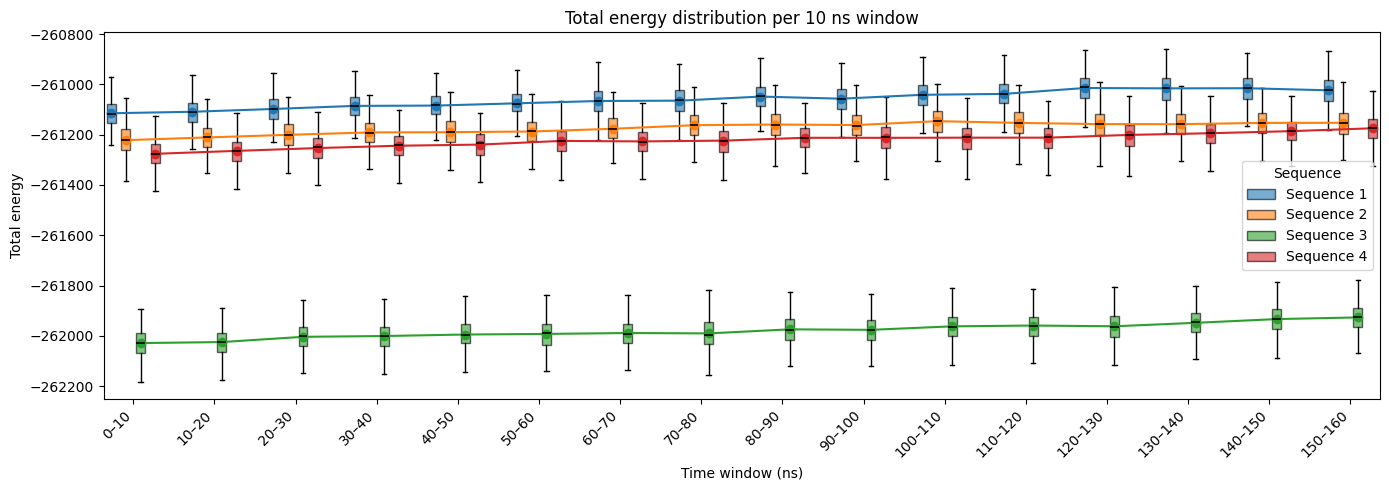

In [4]:
all_energies = [
    load_energies_csv("energies1.csv"),
    load_energies_csv("energies2.csv"),
    load_energies_csv("energies3.csv"),
    load_energies_csv("energies4.csv"),
]
run_labels = ["Sequence 1", "Sequence 2", "Sequence 3", "Sequence 4"]


skip = 50
steps_per_ns = 50
ns_per_part = 10
part_len = steps_per_ns * ns_per_part
n_parts = 16
n_runs = 4
group_gap = 1.5

positions = []
box_data = []
run_ids_for_each_box = []
centers = []

mean_x = [[] for _ in range(n_runs)]
mean_y = [[] for _ in range(n_runs)]

for part in range(n_parts):
    start = skip + part * part_len
    end   = skip + (part + 1) * part_len
    group_start = part * (n_runs + group_gap)

    for run_idx, e in enumerate(all_energies):
        seg_clean = clean_segment(e["Etot"][start:end])
        if seg_clean.size == 0:
            continue

        x_pos = group_start + run_idx

        box_data.append(seg_clean)
        positions.append(x_pos)
        run_ids_for_each_box.append(run_idx)

        mean_x[run_idx].append(x_pos)
        mean_y[run_idx].append(float(np.mean(seg_clean)))

    centers.append(group_start + (n_runs - 1) / 2)


plt.figure(figsize=(14, 5))

bp = plt.boxplot(
    box_data,
    positions=positions,
    widths=0.6,
    whis=1.5,
    showfliers=False,
    patch_artist=True
)

cmap = plt.get_cmap("tab10")
run_colors = [cmap(i) for i in range(n_runs)]

for box, rid in zip(bp["boxes"], run_ids_for_each_box):
    box.set_facecolor(run_colors[rid])
    box.set_alpha(0.6)
    box.set_edgecolor("black")
    box.set_linewidth(1.0)

for w in bp["whiskers"]:
    w.set_color("black")
for c in bp["caps"]:
    c.set_color("black")
for m in bp["medians"]:
    m.set_color("black")
    m.set_linewidth(1.2)

for r in range(n_runs):
    if len(mean_x[r]) >= 2:
        plt.plot(mean_x[r], mean_y[r], marker="o", linewidth=1.5, color=run_colors[r])
    elif len(mean_x[r]) == 1:
        plt.plot(mean_x[r], mean_y[r], marker="o", linestyle="None", color=run_colors[r])

labels = [f"{i*ns_per_part}–{(i+1)*ns_per_part}" for i in range(n_parts)]
plt.xticks(centers, labels, rotation=45, ha="right")

plt.xlabel("Time window (ns)")
plt.ylabel("Total energy")
plt.title("Total energy distribution per 10 ns window")

legend_handles = [
    Patch(facecolor=run_colors[i], edgecolor="black", alpha=0.6, label=run_labels[i])
    for i in range(n_runs)
]
plt.legend(handles=legend_handles, title="Sequence", loc="best")

plt.tight_layout()
plt.show()
